<a href="https://colab.research.google.com/github/muppadivignesh-del/Machine-Learning_Lab_Experiments/blob/main/skill_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab/synthetic_student_performance.csv'

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (5000, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1
5,1006,18,0,3,4,13,23,1,2,1,0,1,0,4.000000,0
6,1007,15,1,0,3,14,25,0,2,1,0,1,1,3.009268,1
7,1008,15,0,0,4,11,8,0,3,0,0,1,1,4.000000,0
8,1009,17,1,1,1,11,23,0,2,0,0,0,0,3.944525,0
9,1010,16,1,3,4,7,11,0,3,0,1,1,1,2.735138,2


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget Distribution:")
display(df["GradeClass"].value_counts().sort_index().to_frame("Count"))

Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Target Distribution:


,Count
GradeClass,
0,2175
1,1152
2,1023
3,650


In [ ]:
features = [
    c for c in df.select_dtypes(include="number").columns
    if c not in ["StudentID", "GradeClass"]
]

X = df[features]
y = df["GradeClass"]

print("Features used:")
print(features)

print("\nFeature Data:")
display(X.head())

Features used:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']

Feature Data:


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,17,1,1,3,16,13,0,2,0,0,0,0,3.158425
1,18,1,2,0,17,28,0,2,1,1,1,0,2.794655
2,15,1,0,1,13,18,1,4,0,0,0,1,3.774847
3,17,1,0,3,6,4,0,3,1,0,0,0,3.040574
4,17,0,1,2,6,20,0,4,0,0,0,0,3.382310


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 4000
Testing samples : 1000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
oob_error = 1 - rf.oob_score_

print("===== RANDOM FOREST =====")
print("Test Accuracy :", round(rf_accuracy, 4))
print("OOB Score     :", round(rf.oob_score_, 4))
print("OOB Error     :", round(oob_error, 4))

===== RANDOM FOREST =====
Test Accuracy : 0.998
OOB Score     : 0.9955
OOB Error     : 0.0045


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,Number of Trees,OOB Error
0,10,0.07400
1,20,0.03175
2,40,0.01050
3,60,0.00475
4,80,0.00450
5,100,0.00450
6,150,0.00400
7,200,0.00275


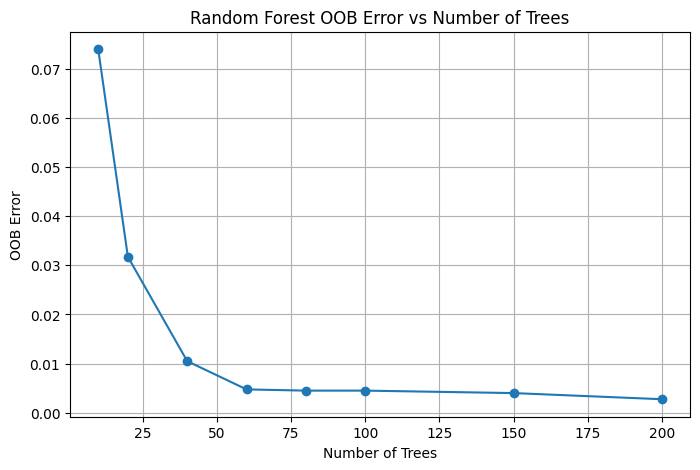

In [ ]:
import matplotlib.pyplot as plt

tree_numbers = [10, 20, 40, 60, 80, 100, 150, 200]
oob_errors = []

for n in tree_numbers:
    model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42
    )

    model.fit(X_train, y_train)
    oob_errors.append(1 - model.oob_score_)

# Create table
oob_table = pd.DataFrame({
    "Number of Trees": tree_numbers,
    "OOB Error": oob_errors
})

display(oob_table)

# Create graph
plt.figure(figsize=(8, 5))
plt.plot(tree_numbers, oob_errors, marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error vs Number of Trees")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

bag_accuracy = accuracy_score(y_test, bag_pred)

print("===== BAGGING =====")
print("Bagging Accuracy:", round(bag_accuracy, 4))

===== BAGGING =====
Bagging Accuracy: 1.0


In [ ]:
rf_subsample = RandomForestClassifier(
    n_estimators=100,
    max_features=2,
    oob_score=True,
    random_state=42
)

rf_subsample.fit(X_train, y_train)

sub_pred = rf_subsample.predict(X_test)

sub_accuracy = accuracy_score(y_test, sub_pred)
sub_oob_error = 1 - rf_subsample.oob_score_

print("===== FEATURE SUBSAMPLING =====")
print("Features considered at each split:", 2)
print("Accuracy :", round(sub_accuracy, 4))
print("OOB Score:", round(rf_subsample.oob_score_, 4))
print("OOB Error:", round(sub_oob_error, 4))

===== FEATURE SUBSAMPLING =====
Features considered at each split: 2
Accuracy : 0.989
OOB Score: 0.979
OOB Error: 0.021


===== MODEL COMPARISON =====


,Model,Accuracy
0,Random Forest,0.998
1,Bagging,1.000
2,Feature Subsampling,0.989


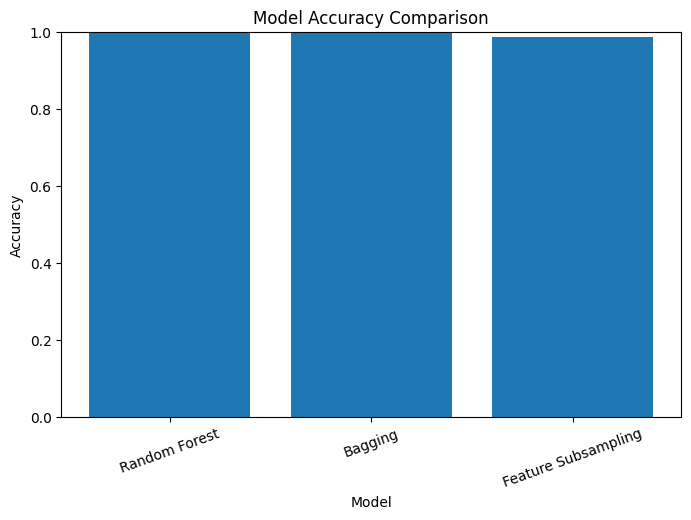

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "Feature Subsampling"
    ],
    "Accuracy": [
        rf_accuracy,
        bag_accuracy,
        sub_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(4)

print("===== MODEL COMPARISON =====")
display(comparison)

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

===== FEATURE IMPORTANCE =====


,Feature,Importance
12,GPA,0.728962
4,StudyTimeWeekly,0.068704
5,Absences,0.063710
7,ParentalSupport,0.024973
3,ParentalEducation,0.023255
0,Age,0.020231
2,Ethnicity,0.016933
1,Gender,0.009994
8,Extracurricular,0.009425
9,Sports,0.009397


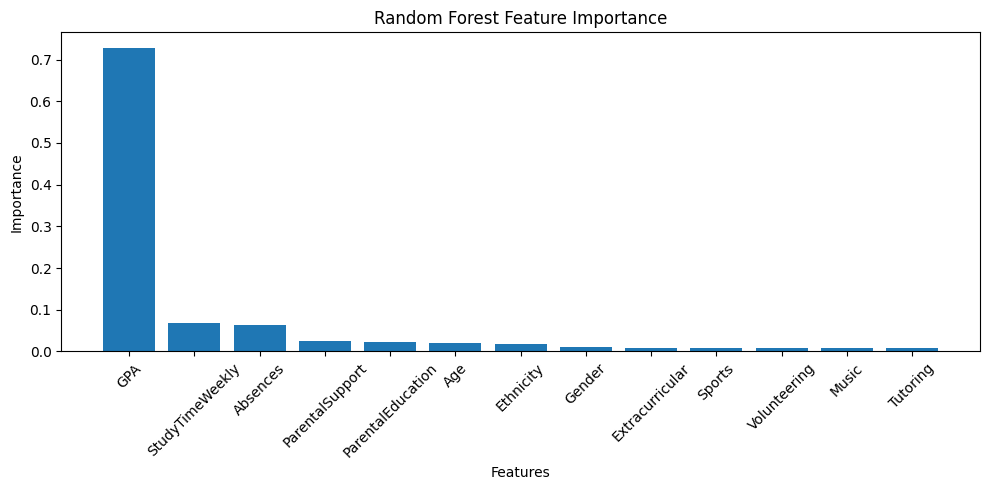


===== FINAL RESULTS =====
Random Forest Accuracy : 0.998
Random Forest OOB Error: 0.0045
Bagging Accuracy       : 1.0
Subsampling Accuracy   : 0.989


In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("===== FEATURE IMPORTANCE =====")
display(importance)

# Feature importance graph
plt.figure(figsize=(10, 5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n===== FINAL RESULTS =====")
print("Random Forest Accuracy :", round(rf_accuracy, 4))
print("Random Forest OOB Error:", round(oob_error, 4))
print("Bagging Accuracy       :", round(bag_accuracy, 4))
print("Subsampling Accuracy   :", round(sub_accuracy, 4))